<a id="top"></a>
# House Sales: valutare un modello di regressione

Nell'esercitazione House Sales avete allenato un modello di regressione per prevedere il prezzo di vendita.
Qui ci concentriamo su come **valutare** le previsioni e su come **raccontare i numeri** al business.

<a id="indice"></a>
## Indice

- [Collegamento all'esercitazione House Sales](#collegamento-esercitazione)
- [Metriche fondamentali per la regressione](#metriche-regressione)
- [Esempio numerico con MAE, RMSE e R²](#esempio-metriche)
- [Applicazione guidata al vostro modello](#applicazione-guidata)


<a id="collegamento-esercitazione"></a>
## Collegamento all'esercitazione House Sales

Nel caso House Sales il target non è binario ma **continuo**: il prezzo di vendita della casa.
Il modello non risponde "sì/no", ma produce un **valore numerico** per ogni immobile.

Per capire se il PoC è credibile bisogna rispondere a domande del tipo:

- quanto sbagliamo in media, in euro;
- quanto pesa l'errore rispetto al prezzo medio delle case;
- quanto del "segnale" sul prezzo riusciamo a spiegare.


<a id="metriche-regressione"></a>
## Metriche fondamentali per la regressione

Si indicano con \(y_i\) i valori reali del prezzo e con \(\hat{y}_i\) le previsioni del modello, per \(i = 1, \dots, n\).

**1. Mean Absolute Error (MAE)**  
Errore medio assoluto, comodo da leggere in **euro**:

$ \text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| $

Un MAE di 18.000 € significa che, in media, il modello sbaglia il prezzo di circa 18.000 €.

**2. Mean Squared Error (MSE) e Root Mean Squared Error (RMSE)**  
Penalizzano di più gli errori grandi; l'RMSE riporta l'unità di misura agli euro:

$ \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \ $ 

$  \text{RMSE} = \sqrt{\text{MSE}} \ $ 

Quando si comunica al business è più naturale usare l'RMSE, perché è in euro come il MAE.

**3. Metriche percentuali (ad esempio MAPE)**  
Per dare una lettura relativa rispetto al valore della casa:

$  \text{MAPE} = \frac{100}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \ $ 

Se il MAPE è intorno al 6\%, si può dire che l'errore medio relativo è circa il 6\% del prezzo reale.

**4. Coefficiente di determinazione (R²)**  
Misura quanta parte della variabilità del prezzo viene spiegata dal modello:

$  R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} \ $ 

dove \(\bar{y}\) è la media dei prezzi reali.
Un R² pari a 0.80 indica che il modello spiega circa l'80\% della variabilità osservata nei prezzi.

<div style="background-color:#f5f5f5; padding:10px; border-left:4px solid #999;">
<strong>Nota importante</strong><br>
Nella comunicazione al business ha senso combinare una <em>metrica in euro</em> (MAE o RMSE)
con una <em>metrica percentuale</em> (MAPE) o con l'R², per collegare l'errore sia in valore assoluto
sia in termini relativi.
</div>


## STEP 1: Valutazione dei modelli 

Preparando il dataset come nell'esercitazione precedente allena Linear Regression e calcolate tutte le metriche definite sopra.


In [1]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

In [2]:
# Importa pandas per gestire i dati in forma tabellare (DataFrame).
import pandas as pd
# Importa la funzione di scikit-learn che scarica dataset da OpenML.
from sklearn.datasets import fetch_openml

# Scarica House Sales (ID OpenML 42092); as_frame=True richiede dati in formato pandas.
raw = fetch_openml(data_id=42092, as_frame=True)
# Copia la tabella che contiene le feature e la colonna prezzo.
house = raw.frame.copy()

# Controlla quante osservazioni (righe) e variabili (colonne) sono state caricate.
print("Dimensioni del dataset (righe, colonne):", house.shape)
# Mostra le prime righe per verificare la struttura e alcuni valori del dataset.
house.head()


Dimensioni del dataset (righe, colonne): (21613, 20)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [3]:
# Importa la configurazione che permette ai trasformatori di restituire DataFrame.
from sklearn import set_config
# Importa la funzione che divide i dati in insiemi di training e test.
from sklearn.model_selection import train_test_split
# Mantiene i nomi delle colonne durante il preprocessing (output in formato pandas).
set_config(transform_output="pandas")


In [4]:
# Elenca le colonne che l'esercitazione esclude dalle feature usate dal modello.
colonne_da_rimuovere = [
    "date", "zipcode", "lat", "long", "yr_built", "yr_renovated"
]

# Crea X con le variabili esplicative, rimuovendo sia il target sia le colonne escluse.
X = house.drop(columns=["price", *colonne_da_rimuovere])
# Crea y con il valore che il modello dovrà imparare a prevedere: il prezzo.
y = house["price"]

# Divide feature e target: 70% per addestrare, 30% per valutare su dati separati.
# random_state rende sempre uguale la divisione quando si riesegue il notebook.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Stampa le dimensioni per verificare che X e y siano stati divisi coerentemente.
print("Dimensioni training:", X_train.shape, y_train.shape)
print("Dimensioni test:", X_test.shape, y_test.shape)

Dimensioni training: (15129, 13) (15129,)
Dimensioni test: (6484, 13) (6484,)


In [5]:
# Importa Pipeline per concatenare i passaggi di preprocessing in sequenza.
from sklearn.pipeline import Pipeline
# Importa lo strumento che sostituisce eventuali valori mancanti.
from sklearn.impute import SimpleImputer
# Importa lo scaler robusto, meno sensibile ai valori estremi.
from sklearn.preprocessing import RobustScaler


In [6]:
# Seleziona i nomi delle colonne di X_train che non hanno un tipo numerico.
colonne_non_numeriche = X_train.select_dtypes(exclude="number").columns
# Un elenco vuoto conferma che tutte le feature possono essere trattate numericamente.
print("Colonne non numeriche:", list(colonne_non_numeriche))

# Definisce il preprocessing in ordine: prima imputazione, poi normalizzazione robusta.
preprocessing_pipeline = Pipeline(steps=[
    # Sostituisce eventuali valori mancanti di ogni feature con la sua mediana.
    ("imputer", SimpleImputer(strategy="median")),
    # Centra e scala le feature usando statistiche robuste agli outlier.
    ("scaler", RobustScaler())
])

Colonne non numeriche: []


In [7]:
# Importa Pipeline per costruire la pipeline completa del modello.
from sklearn.pipeline import Pipeline
# Importa il modello lineare di regressione che predice un prezzo continuo.
from sklearn.linear_model import LinearRegression


In [8]:
# Crea una pipeline completa: trasforma le feature e poi applica la regressione.
model_pipeline = Pipeline(steps=[
    # Esegue imputazione e scaling definiti nella pipeline di preprocessing.
    ("preprocessing", preprocessing_pipeline),
    # Impara una relazione lineare tra le feature e il prezzo.
    ("regression", LinearRegression())
])

# Adatta tutti i passaggi ai dati di training e apprende i coefficienti del modello.
model_pipeline.fit(X_train, y_train)
# Usa il modello addestrato per stimare il prezzo delle case nell'insieme di test.
y_pred = model_pipeline.predict(X_test)

# Affianca prezzi osservati e previsti; gli indici consentono di associare le righe.
confronto = pd.DataFrame({
    "Prezzo reale": y_test,
    "Prezzo previsto": y_pred
})
# Visualizza le prime righe del confronto.
confronto.head()

,Prezzo reale,Prezzo previsto
735,365000.0,5.539663e+05
2830,865000.0,7.523221e+05
4106,1038000.0,1.251868e+06
16218,1490000.0,1.519499e+06
19964,711000.0,7.280434e+05


In [9]:
# Calcola le metriche sui prezzi reali e previsti del test set.
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
r2 = r2_score(y_test, y_pred)

# Mostra gli errori in euro e le metriche relative in un formato leggibile.
print(f"MAE:  {mae:,.2f} €")
print(f"MSE:  {mse:,.2f} €²")
print(f"RMSE: {rmse:,.2f} €")
print(f"MAPE: {mape:.2f}%")
print(f"R²:   {r2:.4f}")

MAE:  154,646.96 €
MSE:  56,620,219,133.95 €²
RMSE: 237,950.03 €
MAPE: 31.64%
R²:   0.6078


## STEP 2: Migliora

Si può migliorare solo quello che possiamo misurare. Ora che sappiamo misurarlo proviamo diversi modelli e vediamo quale ottiene migliori performance.

Allena anche Random Forest Regressor e confronta le metriche

In [10]:
from sklearn.ensemble import RandomForestRegressor

# Crea e allena una pipeline con Random Forest.
rf_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessing_pipeline),
    ("regression", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

# Calcola le metriche della Random Forest.
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf) * 100
r2_rf = r2_score(y_test, y_pred_rf)

# Confronta i risultati con quelli della regressione lineare.
pd.DataFrame({
    "Modello": ["Linear Regression", "Random Forest"],
    "MAE (€)": [mae, mae_rf],
    "RMSE (€)": [rmse, rmse_rf],
    "MAPE (%)": [mape, mape_rf],
    "R²": [r2, r2_rf]
}).set_index("Modello").round(2)

,MAE (€),RMSE (€),MAPE (%),R²
Modello,,,,
Linear Regression,154646.96,237950.03,31.64,0.61
Random Forest,127989.47,210556.68,25.75,0.69


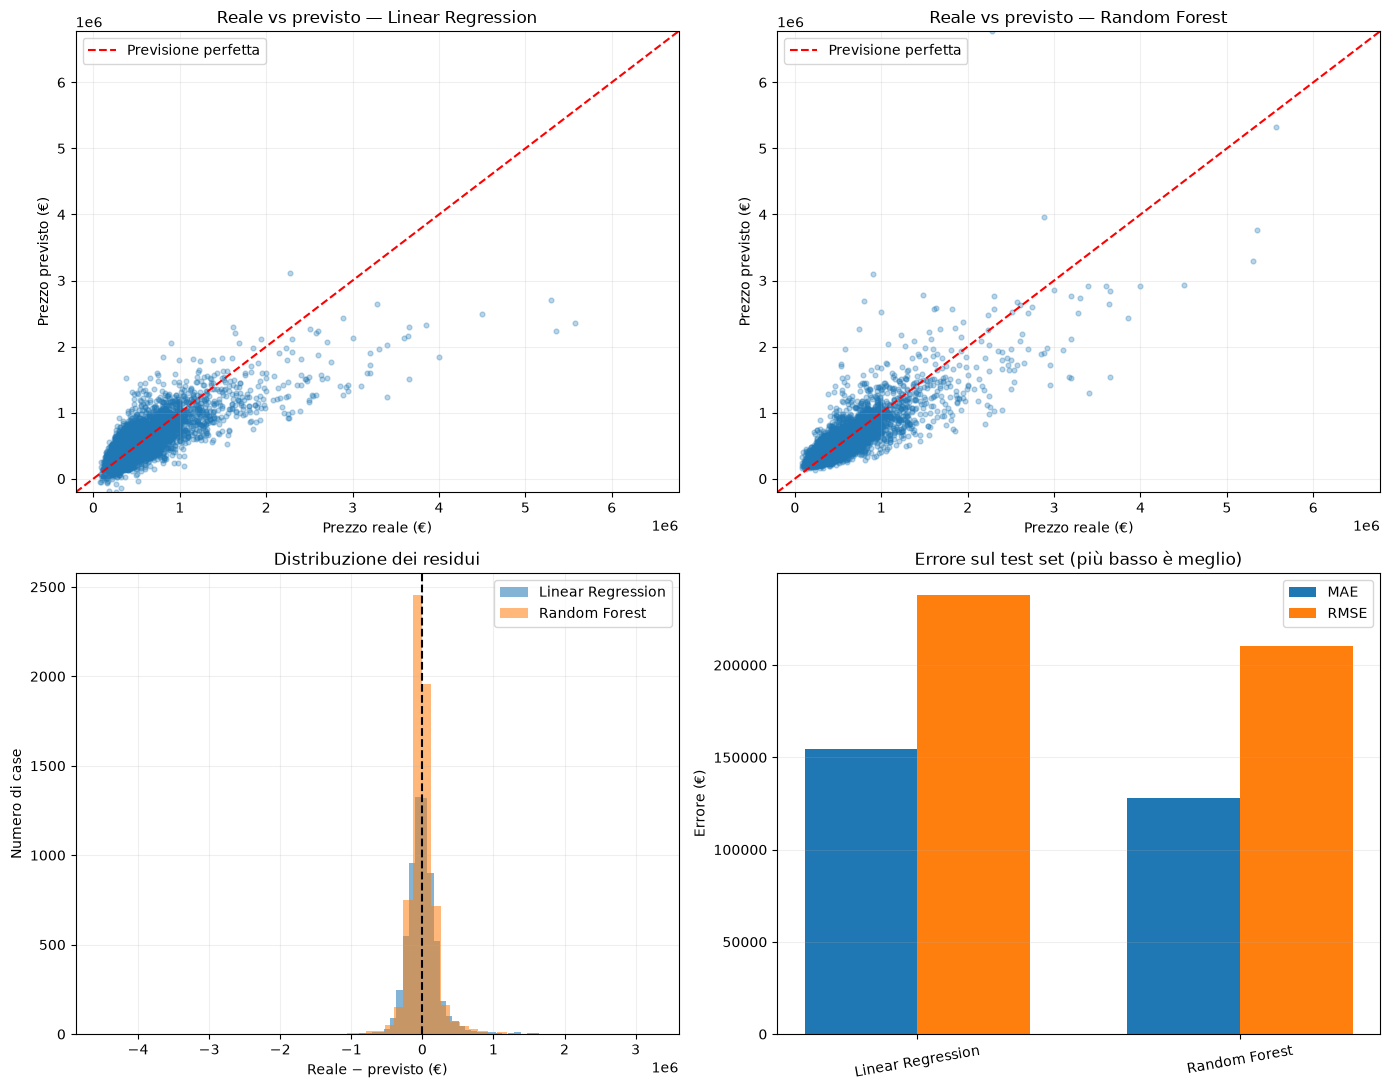

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Reale vs previsto: più i punti sono vicini alla diagonale, meglio il modello fitta.
limite = [min(y_test.min(), y_pred.min(), y_pred_rf.min()),
          max(y_test.max(), y_pred.max(), y_pred_rf.max())]

for ax, predizioni, nome in [
    (axes[0, 0], y_pred, "Linear Regression"),
    (axes[0, 1], y_pred_rf, "Random Forest")
]:
    ax.scatter(y_test, predizioni, alpha=0.3, s=12)
    ax.plot(limite, limite, "r--", label="Previsione perfetta")
    ax.set(xlabel="Prezzo reale (€)", ylabel="Prezzo previsto (€)",
           title=f"Reale vs previsto — {nome}", xlim=limite, ylim=limite)
    ax.legend()
    ax.grid(alpha=0.2)

# Distribuzione degli errori: residui vicini a zero sono preferibili.
residui_lr = y_test.to_numpy() - y_pred
residui_rf = y_test.to_numpy() - y_pred_rf
axes[1, 0].hist(residui_lr, bins=50, alpha=0.55, label="Linear Regression")
axes[1, 0].hist(residui_rf, bins=50, alpha=0.55, label="Random Forest")
axes[1, 0].axvline(0, color="black", linestyle="--")
axes[1, 0].set(title="Distribuzione dei residui", xlabel="Reale − previsto (€)",
               ylabel="Numero di case")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.2)

# Confronto degli errori: valori più bassi sono migliori.
modelli = ["Linear Regression", "Random Forest"]
x = np.arange(len(modelli))
larghezza = 0.35
axes[1, 1].bar(x - larghezza / 2, [mae, mae_rf], larghezza, label="MAE")
axes[1, 1].bar(x + larghezza / 2, [rmse, rmse_rf], larghezza, label="RMSE")
axes[1, 1].set_xticks(x, modelli, rotation=10)
axes[1, 1].set(title="Errore sul test set (più basso è meglio)",
               ylabel="Errore (€)")
axes[1, 1].legend()
axes[1, 1].grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

## STEP 3: Spiega

Usa PFI e SHAP per verificare quali sono le varibaili più importanti e come impattano. Scrivi due righe per riassumere.

In [13]:
%pip install -U ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]3 [ipywidgets]
Note: you may need to restart the kernel to use updated packages.


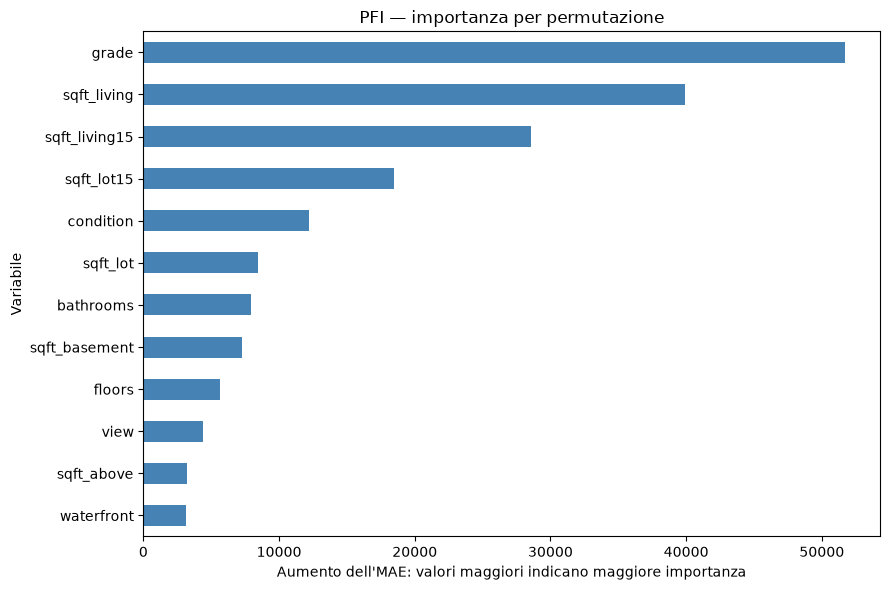

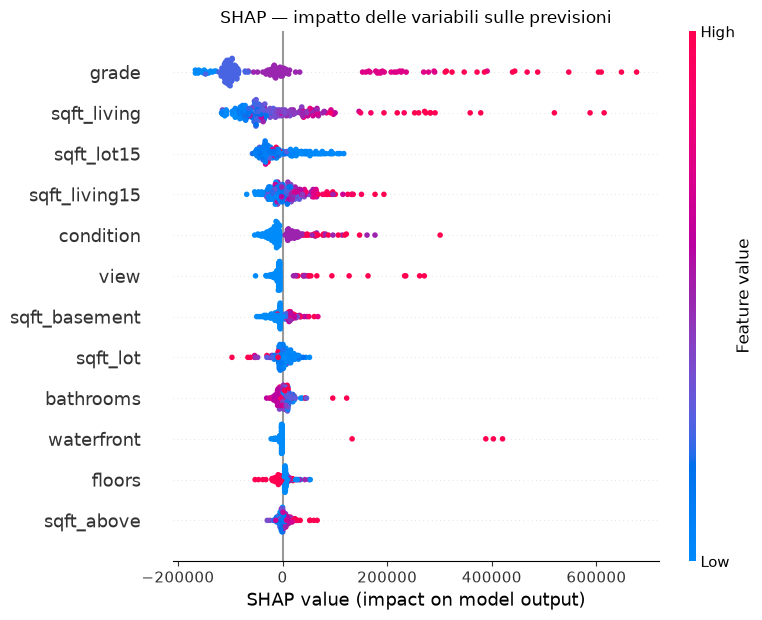

,PFI: aumento MAE (€),SHAP medio assoluto (€)
grade,51701.93,122408.00
sqft_living,39929.19,74583.81
sqft_lot15,18478.41,32970.57
sqft_living15,28548.66,30695.17
condition,12182.55,28019.43
view,4421.11,18633.82
sqft_basement,7304.34,14900.57
sqft_lot,8471.26,11474.48
bathrooms,7906.33,10326.37
waterfront,3169.76,9552.95


Commento sui risultati:
- PFI: le variabili più importanti sono grade, sqft_living, sqft_living15, sqft_lot15, condition.
- SHAP: le variabili con maggiore impatto medio sono grade, sqft_living, sqft_lot15, sqft_living15, condition.
- Tra le prime cinque di entrambi i metodi compaiono: grade, sqft_living, sqft_living15, sqft_lot15, condition.
- Nel grafico SHAP, valori positivi spingono la previsione sopra il valore di riferimento; valori negativi la spingono sotto. Il colore rappresenta il valore basso o alto della variabile.
- PFI e SHAP descrivono associazioni apprese dal modello, non effetti causali. Variabili correlate possono influenzarsi a vicenda nelle classifiche.


In [14]:
from sklearn.inspection import permutation_importance

try:
    import shap
except ImportError as exc:
    raise ImportError(
        "Installa SHAP con `%pip install shap` e riesegui questa cella."
    ) from exc

# PFI su un campione riproducibile: meno righe e ripetizioni riducono i tempi.
X_pfi = X_test.sample(n=min(2000, len(X_test)), random_state=42)
y_pfi = y_test.loc[X_pfi.index]
pfi = permutation_importance(
    rf_pipeline,
    X_pfi,
    y_pfi,
    scoring="neg_mean_absolute_error",
    n_repeats=5,
    random_state=42,
    n_jobs=1
)
pfi_importance = pd.Series(
    pfi.importances_mean,
    index=X_test.columns,
    name="Aumento MAE (€)"
).sort_values(ascending=False)

ax = pfi_importance.head(12).sort_values().plot(
    kind="barh", figsize=(9, 6), color="steelblue"
)
ax.set_title("PFI — importanza per permutazione")
ax.set_xlabel("Aumento dell'MAE: valori maggiori indicano maggiore importanza")
ax.set_ylabel("Variabile")
plt.tight_layout()
plt.show()

# SHAP su un campione più piccolo per contenere i tempi di calcolo.
rf_model = rf_pipeline.named_steps["regression"]
X_test_trasformato = pd.DataFrame(
    rf_pipeline.named_steps["preprocessing"].transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)
X_shap = X_test_trasformato.sample(
    n=min(200, len(X_test_trasformato)), random_state=42
)

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_shap)
if isinstance(shap_values, list):
    shap_values = shap_values[0]
if np.ndim(shap_values) == 3:
    shap_values = shap_values[:, :, 0]

shap.summary_plot(shap_values, X_shap, show=False, max_display=12)
plt.title("SHAP — impatto delle variabili sulle previsioni")
plt.tight_layout()
plt.show()

shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_shap.columns,
    name="SHAP medio assoluto (€)"
).sort_values(ascending=False)

display(pd.concat(
    [
        pfi_importance.rename("PFI: aumento MAE (€)"),
        shap_importance.rename("SHAP medio assoluto (€)")
    ],
    axis=1
).sort_values("SHAP medio assoluto (€)", ascending=False).head(12).round(2))

top_pfi = pfi_importance.head(5).index.tolist()
top_shap = shap_importance.head(5).index.tolist()
comuni = [feature for feature in top_pfi if feature in top_shap]

print("Commento sui risultati:")
print(f"- PFI: le variabili più importanti sono {', '.join(top_pfi)}.")
print(f"- SHAP: le variabili con maggiore impatto medio sono {', '.join(top_shap)}.")
print(
    f"- Tra le prime cinque di entrambi i metodi compaiono: "
    f"{', '.join(comuni) if comuni else 'nessuna variabile'}."
)
print(
    "- Nel grafico SHAP, valori positivi spingono la previsione sopra "
    "il valore di riferimento; valori negativi la spingono sotto. "
    "Il colore rappresenta il valore basso o alto della variabile."
)
print(
    "- PFI e SHAP descrivono associazioni apprese dal modello, non effetti causali. "
    "Variabili correlate possono influenzarsi a vicenda nelle classifiche."
)


## Extra:

Non sollo l'algoritmo impatta sulle performance, prova a settare diversamente i parametri del modello (iperparametri) come max_depth per Random Forest e verifica se le performance migliorano. Registra la performance migliore che sei riuscito ad ottenere. 

,max_depth,MAE,RMSE,MAPE (%),R²
0,Illimitata,126232.20,190986.01,25.95,0.76
1,5,141461.93,209450.48,29.57,0.71
2,10,127760.22,192098.89,26.41,0.76
3,15,125867.02,190679.80,25.88,0.76
4,20,126044.95,190872.24,25.91,0.76
5,30,126240.49,190880.78,25.96,0.76


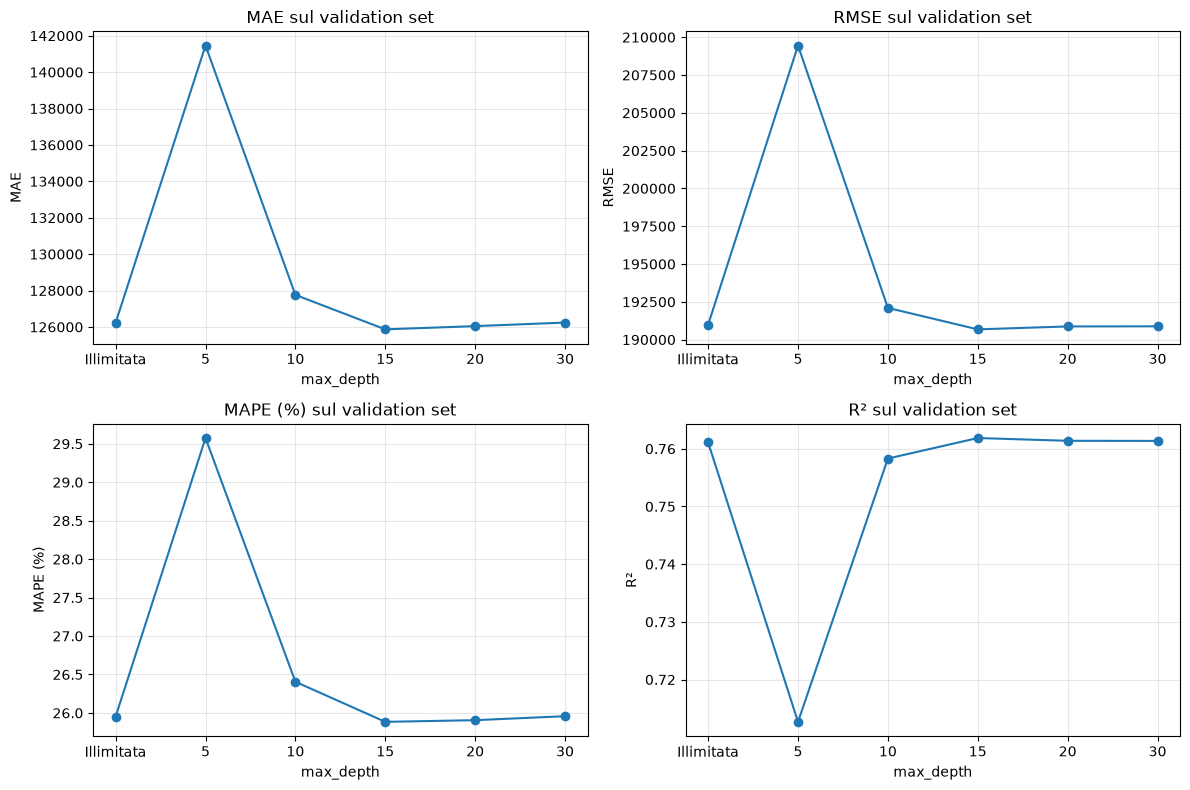

Profondità migliore secondo RMSE di validation: 15

Metriche sul test set per il modello selezionato:
MAE:  128,223.74 €
RMSE: 210,646.88 €
MAPE: 25.78%
R²:   0.6926


In [15]:
# Confronta diverse profondità usando una porzione del training set come validation.
X_train_depth, X_val_depth, y_train_depth, y_val_depth = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42
)

profondita = [None, 5, 10, 15, 20, 30]
risultati_depth = []

for profondita_max in profondita:
    pipeline_depth = Pipeline(steps=[
        ("preprocessing", preprocessing_pipeline),
        ("regression", RandomForestRegressor(
            n_estimators=200,
            max_depth=profondita_max,
            random_state=42,
            n_jobs=-1
        ))
    ])
    pipeline_depth.fit(X_train_depth, y_train_depth)
    predizioni_val = pipeline_depth.predict(X_val_depth)

    risultati_depth.append({
        "max_depth": "Illimitata" if profondita_max is None else str(profondita_max),
        "MAE": mean_absolute_error(y_val_depth, predizioni_val),
        "RMSE": np.sqrt(mean_squared_error(y_val_depth, predizioni_val)),
        "MAPE (%)": mean_absolute_percentage_error(y_val_depth, predizioni_val) * 100,
        "R²": r2_score(y_val_depth, predizioni_val)
    })

risultati_depth = pd.DataFrame(risultati_depth)
display(risultati_depth.round(2))

# Diagramma delle metriche di validation; per MAE, RMSE e MAPE più basso è meglio,
# mentre per R² più alto è meglio.
fig, assi = plt.subplots(2, 2, figsize=(12, 8))
metriche = ["MAE", "RMSE", "MAPE (%)", "R²"]

for asse, metrica in zip(assi.flat, metriche):
    asse.plot(risultati_depth["max_depth"], risultati_depth[metrica], marker="o")
    asse.set_title(f"{metrica} sul validation set")
    asse.set_xlabel("max_depth")
    asse.set_ylabel(metrica)
    asse.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Seleziona la profondità con il RMSE di validation più basso.
migliore = risultati_depth.loc[risultati_depth["RMSE"].idxmin()]
profondita_migliore = (
    None if migliore["max_depth"] == "Illimitata"
    else int(migliore["max_depth"])
)
print(f"Profondità migliore secondo RMSE di validation: {migliore['max_depth']}")

# Riaddestra sul training set completo e valuta una sola volta sul test set.
rf_depth_best = Pipeline(steps=[
    ("preprocessing", preprocessing_pipeline),
    ("regression", RandomForestRegressor(
        n_estimators=200,
        max_depth=profondita_migliore,
        random_state=42,
        n_jobs=-1
    ))
])
rf_depth_best.fit(X_train, y_train)
y_pred_depth_best = rf_depth_best.predict(X_test)

print("\nMetriche sul test set per il modello selezionato:")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_depth_best):,.2f} €")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_depth_best)):,.2f} €")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_depth_best) * 100:.2f}%")
print(f"R²:   {r2_score(y_test, y_pred_depth_best):.4f}")